In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import sys
from scipy.special import legendre
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sys.path.insert(1, '../../scripts')
import CMBanom

In [38]:
# Parameters
Nsims         = 100000
index_Hayley  = 2
index_Planck  = 6

# Anomaly-specific params
mu_index      = 14
R_index    = 27

In [29]:
# Directories
stats_dir = "../../data/stats/"

# Planck maps  
labels_Planck = [ r"$70\, \mathrm{GHz}$",  r"$94\, \mathrm{GHz}$", r"$100\, \mathrm{GHz}$", r"$143\, \mathrm{GHz}$", r"$\mathrm{Commander}$", r"$\mathrm{NILC}$", r"$\mathrm{SEVEM}$", r"$\mathrm{SMICA}$"]
colors_Planck = [  "tab:red", "teal",  "navy",  "gold", "tab:red",    "teal",   "navy",   "gold"]
lss_Planck    = [        "-",    "-",     "-",     "-",      "--",      "--",     "--",     "--"]
color_qml     = "green"
label_qml     = r"$\mathrm{Public\ QML-}C_\ell$"
index_Hayley  = 2
index_Planck  = 6
Nmaps = len(labels_Planck)

# Masks
names_mask       = [              "fullsky",                "stdmask",                  "commask"]
names_mask_table = [             "full sky",              "std. mask",                "com. mask"]
labels_mask      = [r"$\mathrm{Full\ sky}$", r"$\mathrm{Std.\ mask}$", r"$\mathrm{Common\ mask}$"]
colors_mask      = [             "tab:blue",                   "navy",                "firebrick"]
Nmasks = len(labels_mask)

In [6]:
# Font
plt.rc('font',**{'family':'Helvetica','size':20})
plt.rc('text', usetex=True)
font = {'family':'Helvetica',
        'color' : 'black',
        'size'  :  20}

In [37]:
# Load stats
Smu_sims = np.array([np.loadtxt(stats_dir+f"Smu_sims_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)])
Smu_real = np.load(stats_dir+"Smu_real.npy")
Smu_PQML = np.load(stats_dir+"Smu_real_QML.npy")

R_sims = np.array([np.loadtxt(stats_dir+f"R_sims_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)])
R_real = np.load(stats_dir+"R_real.npy")
R_PQML = np.load(stats_dir+"R_real_QML.npy")

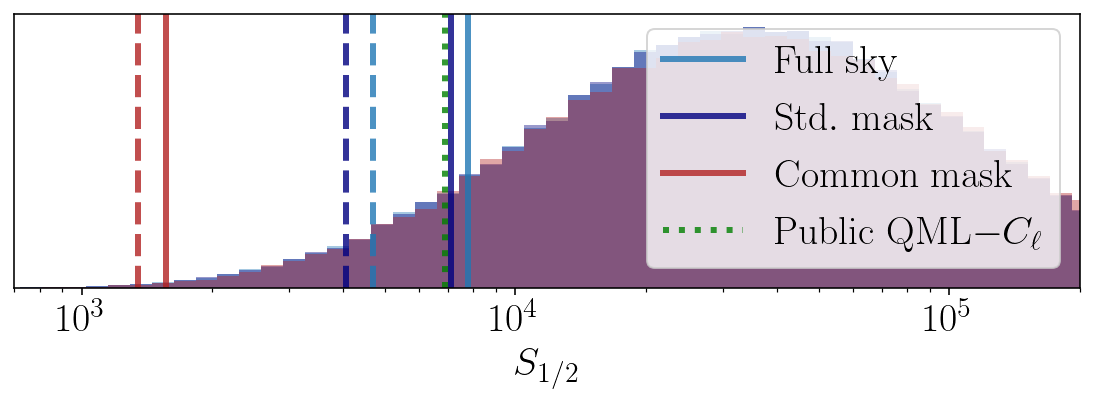

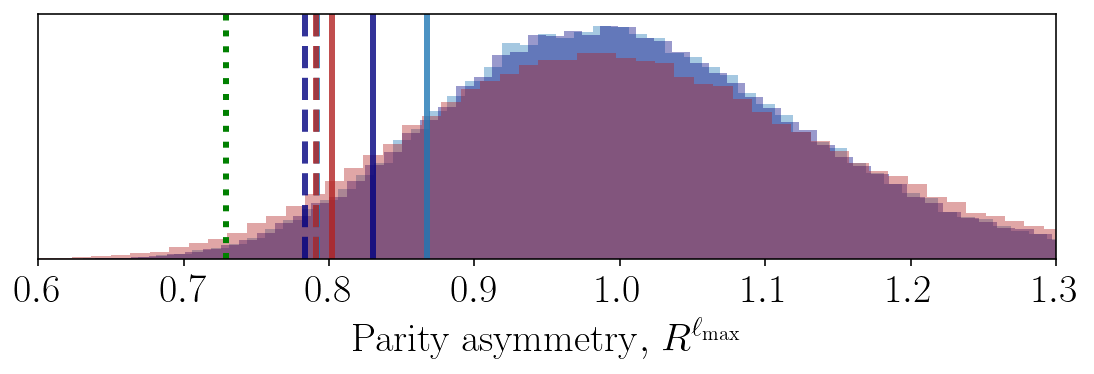

In [45]:
fig = plt.figure(figsize=(8, 3.2))
bins = 10**np.linspace(2, 7, 100)
for m in range(Nmasks):
    h=plt.hist(Smu_sims[m][mu_index], bins=bins, color=colors_mask[m], alpha=0.4)
    plt.axvline(Smu_real[m][index_Hayley][mu_index], color=colors_mask[m], lw=3, alpha=0.8, ls="-", label=labels_mask[m])
    plt.axvline(Smu_real[m][index_Planck][mu_index], color=colors_mask[m], lw=3, alpha=0.8, ls="--")
plt.axvline(Smu_PQML[mu_index], color=color_qml, lw=3, alpha=0.8, ls=":", label=label_qml)
plt.xlim(7e2, 2e5)
plt.xscale("log")
plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
plt.xlabel(r"$S_{1/2}$")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(8, 3))
#plt.plot([0], [0], color='grey', ls="-", lw=3, label=labels_Planck[index_Hayley])
#plt.plot([0], [0], color='grey', ls="--", lw=3, label=labels_Planck[index_Planck])
for m in range(Nmasks):
    h=plt.hist(R_sims[m].T[27], bins=100, alpha=0.4, density=True, color=colors_mask[m])
    plt.axvline(R_real[m][index_Planck][27], color=colors_mask[m], alpha=0.8, lw=3, ls="-", label=labels_mask[m])
    plt.axvline(R_real[m][index_Hayley][27], color=colors_mask[m], alpha=0.8, lw=3, ls="--")
plt.axvline(R_PQML[27], color=color_qml, label=label_qml, ls=":", lw=3)
plt.xlim(0.6, 1.3)
plt.xlabel(r"$\mathrm{Parity\ asymmetry,}\ R^{\ell_\mathrm{max}}$")
plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
#plt.legend(loc="lower right")
plt.tight_layout()
#plt.savefig("hist_Rlmax.pdf", format="PDF")
plt.show()

# Compute p-values and print table

In [39]:
p_Smu_real = np.array([[CMBanom.pval_lower(Smu_real[m][n][mu_index], Smu_sims[m][mu_index]) for n in range(Nmaps)] for m in range(Nmasks)])
p_Smu_PQML = np.array( [CMBanom.pval_lower(Smu_PQML[mu_index], Smu_sims[m][mu_index]) for m in range(Nmasks)])

p_R_real = np.array([[CMBanom.pval_lower(R_real[m][n][R_index], R_sims[m][R_index]) for n in range(Nmaps)] for m in range(Nmasks)])
p_R_PQML = np.array( [CMBanom.pval_lower(R_PQML[R_index], R_sims[m][R_index]) for m in range(Nmasks)])

In [41]:
print("Table 1: p-values")
print("-----------------")
print("    \hline")
for m in range(Nmasks):
    if m==1: print(f"    $S_{{1/2}}$     &{names_mask_table[m]}: ", end="")
    else:    print(f"                  &{names_mask_table[m]}: ", end="")
    for n in range(Nmaps):
        print(f"&{100*p_Smu_real[m][n]:.2f} ", end="")
    print("\\\\")
print("    \hline")
for m in range(Nmasks):
    if m==1: print(f"    $R^{{27}}$      &{names_mask_table[m]}: ", end="")
    else:    print(f"                  &{names_mask_table[m]}: ", end="")
    for n in range(Nmaps):
        print(f"&{100*p_R_real[m][n]:.2f} ", end="")
    print("\\\\")
print("    \hline")

Table 1: p-values
-----------------
    \hline
                  &full sky: &11.01 &11.58 &9.63 &9.34 &4.56 &6.15 &4.02 &6.20 \\
    $S_{1/2}$     &std. mask: &9.77 &9.63 &8.35 &8.01 &5.08 &5.47 &3.02 &5.88 \\
                  &com. mask: &0.27 &0.34 &0.22 &0.24 &0.17 &0.10 &0.14 &0.12 \\
    \hline
                  &full sky: &0.00 &0.00 &0.00 &0.00 &0.00 &0.00 &0.00 &0.00 \\
    $R^{27}$      &std. mask: &0.00 &0.00 &0.00 &0.00 &0.00 &0.00 &0.00 &0.00 \\
                  &com. mask: &0.00 &0.00 &0.00 &0.00 &0.00 &0.00 &0.00 &0.00 \\
    \hline
